# Wav2Lip — Loss ablation (CE / cosine / KL)

Five-way ablation on a single backbone (Wav2Lip) to justify the emotion-loss choice. Same dataset pipeline, encoders, and hyper-params as `04_finetune_wav2lip.ipynb`; only the emotion-loss composition changes.

| name | L1 | cosine | CE | KL | purpose |
|------|:--:|:------:|:--:|:--:|---------|
| `baseline`  | ✓ | — | — | — | reference (no emotion loss) |
| `cos-only`  | ✓ | ✓ | — | — | matches current method |
| `ce-only`   | ✓ | — | ✓ | — | supervised single-modality emotion |
| `ce-cos`    | ✓ | ✓ | ✓ | — | supervised + geometric alignment |
| `ce-kl`     | ✓ | — | ✓ | ✓ | supervised + probabilistic alignment |

Outputs per config are internal encoder-based F1/accuracy; **external classifier evaluation is done in `06_external_evaluation.ipynb`** (separate stage, test split only).

In [1]:
!pip install -q transformers librosa wandb scipy scikit-learn
!git clone https://github.com/Rudrabha/Wav2Lip.git 2>/dev/null || true
!mkdir -p Wav2Lip/checkpoints
!wget -q -nc "https://huggingface.co/Nekochu/Wav2Lip/resolve/main/wav2lip.pth" -O Wav2Lip/checkpoints/wav2lip.pth

In [2]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

import sys
sys.path.insert(0, "/content")
sys.path.insert(0, "/content/Wav2Lip")

import gc
import json
import random
import warnings
from pathlib import Path

import librosa
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import wandb
from sklearn.metrics import f1_score
from torch.amp import GradScaler, autocast
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

from emotion_utils import (
    DifferentiableVideoPreprocess,
    load_frozen_audio_encoder,
    load_frozen_video_encoder,
    extract_audio_embedding,
    extract_video_embedding,
)
from models.wav2lip import Wav2Lip as Wav2LipModel

warnings.filterwarnings("ignore")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
METADATA = "/content/processed_data/metadata.json"
WAV2LIP_CKPT = "/content/Wav2Lip/checkpoints/wav2lip.pth"
BEST_AUDIO_PATH = "/content/trained_encoders_6emotions/6emo-hubert-er-lr3e5-nf"
BEST_VIDEO_PATH = "/content/trained_encoders_6emotions/6emo-tsf-lr3e5-16f-nf"
OUT_DIR = Path("/content/wav2lip_loss_ablation")
OUT_DIR.mkdir(parents=True, exist_ok=True)

EXCLUDE = {0, 1}
REMAP = {2: 0, 3: 1, 4: 2, 5: 3, 6: 4, 7: 5}
EMOTIONS = ["happy", "sad", "angry", "fearful", "disgust", "surprised"]
NUM_EMO = len(EMOTIONS)
WAV2LIP_TO_ENCODER = [2, 3, 4, 5, 6, 7]

print(f"Device: {DEVICE}")

Device: cuda


In [3]:
IMG_SIZE = 96
MEL_STEP = 16
SR = 16000
FPS = 25


def wav_to_mel(wav_path, sr=SR):
    y, _ = librosa.load(wav_path, sr=sr)
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=80, hop_length=200, win_length=800, fmin=55, fmax=7600)
    return librosa.power_to_db(mel, ref=np.max).astype(np.float32)


class Wav2LipDataset(Dataset):
    def __init__(self, metadata_path, split, T=5):
        with open(metadata_path) as f:
            data = json.load(f)
        self.samples = [s for s in data
                        if s["split"] == split and s["emotion_idx"] not in EXCLUDE]
        self.T = T

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        wav, _ = torchaudio.load(s["audio_path"])
        audio_1d = wav.squeeze(0)
        mel = wav_to_mel(s["audio_path"])

        frames = np.load(s["frames_path"]).astype(np.float32) / 255.0
        n_frames = frames.shape[0]
        start = np.random.randint(0, max(1, n_frames - self.T))
        face_window = frames[start:start + self.T]
        if face_window.shape[0] < self.T:
            pad = np.repeat(face_window[-1:], self.T - face_window.shape[0], axis=0)
            face_window = np.concatenate([face_window, pad], axis=0)

        mel_start = int(start / FPS * SR / 200)
        mel_end = mel_start + MEL_STEP * self.T
        mel_window = mel[:, mel_start:mel_end]
        if mel_window.shape[1] < MEL_STEP * self.T:
            mel_window = np.pad(mel_window, ((0, 0), (0, MEL_STEP * self.T - mel_window.shape[1])))

        gt = torch.from_numpy(face_window).permute(0, 3, 1, 2)
        if gt.shape[2] != IMG_SIZE or gt.shape[3] != IMG_SIZE:
            gt = F.interpolate(gt, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)

        masked = gt.clone()
        masked[:, :, IMG_SIZE // 2:, :] = 0.0

        ref_idx = np.random.randint(0, n_frames)
        ref = torch.from_numpy(frames[ref_idx]).permute(2, 0, 1).unsqueeze(0).expand(self.T, -1, -1, -1)
        if ref.shape[2] != IMG_SIZE or ref.shape[3] != IMG_SIZE:
            ref = F.interpolate(ref, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)

        face_input = torch.cat([ref, masked], dim=1)

        mel_chunks = []
        for t in range(self.T):
            m = mel_window[:, t * MEL_STEP:(t + 1) * MEL_STEP]
            mel_chunks.append(torch.from_numpy(m).unsqueeze(0))
        mel_tensor = torch.stack(mel_chunks, dim=0)

        return {
            "mel": mel_tensor,
            "face_input": face_input,
            "gt": gt,
            "audio": audio_1d,
            "emotion": REMAP[s["emotion_idx"]],
        }


def collate_wav2lip(batch):
    return {
        "mel": torch.stack([b["mel"] for b in batch]),
        "face_input": torch.stack([b["face_input"] for b in batch]),
        "gt": torch.stack([b["gt"] for b in batch]),
        "audio": [b["audio"] for b in batch],
        "emotion": torch.tensor([b["emotion"] for b in batch]),
    }

In [4]:
def load_wav2lip(ckpt_path, device, freeze_encoders=True):
    model = Wav2LipModel()
    try:
        ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    except TypeError:
        ckpt = torch.load(ckpt_path, map_location="cpu")
    state = ckpt["state_dict"] if "state_dict" in ckpt else ckpt
    state = {k.replace("module.", ""): v for k, v in state.items()}
    model.load_state_dict(state, strict=False)
    if freeze_encoders:
        for p in model.face_encoder_blocks.parameters():
            p.requires_grad = False
        for p in model.audio_encoder.parameters():
            p.requires_grad = False
    return model.to(device)


audio_enc, audio_proc = load_frozen_audio_encoder(BEST_AUDIO_PATH, DEVICE)
video_enc = load_frozen_video_encoder(BEST_VIDEO_PATH, DEVICE)
video_preprocess = DifferentiableVideoPreprocess(224).to(DEVICE)

VIDEO_ENC_FRAMES = getattr(video_enc.config, "num_frames", 8)
AUDIO_DIM = audio_enc.config.hidden_size
VIDEO_DIM = video_enc.config.hidden_size
PROJ_DIM = 256

AUDIO_HEAD_LABELS = int(getattr(audio_enc.config, "num_labels", NUM_EMO))
VIDEO_HEAD_LABELS = int(getattr(video_enc.config, "num_labels", NUM_EMO))
print(f"Audio head labels: {AUDIO_HEAD_LABELS} | Video head labels: {VIDEO_HEAD_LABELS}")
print(f"Video frames: {VIDEO_ENC_FRAMES} | Audio dim: {AUDIO_DIM} | Video dim: {VIDEO_DIM}")

Audio head labels: 6 | Video head labels: 6
Video frames: 8 | Audio dim: 768 | Video dim: 768


## Composite emotion loss

$$\mathcal{L}_{emo} = w_{CE}\cdot\text{CE}(\hat{y}_v, y) + w_{cos}\cdot (1 - \cos(a_{proj}, v_{proj})) + w_{KL}\cdot T^2\cdot \text{KL}(p_a \parallel p_v)$$

Setting any weight to 0 disables that term (and skips its computation). KL uses temperature $T$ scaling with the standard $T^2$ correction.

In [5]:
class EmotionLossComposite(nn.Module):
    """Composite emotion loss: CE + cosine + KL, any subset active via weights."""

    def __init__(self, w_ce=0.0, w_cos=0.0, w_kl=0.0,
                 label_smoothing=0.1, kl_temperature=2.0):
        super().__init__()
        self.w_ce = w_ce
        self.w_cos = w_cos
        self.w_kl = w_kl
        self.T = kl_temperature
        self.ce = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    @property
    def needs_projections(self):
        return self.w_cos > 0

    @property
    def needs_video_logits(self):
        return self.w_ce > 0 or self.w_kl > 0

    @property
    def needs_audio_logits(self):
        return self.w_kl > 0

    def forward(self, labels, video_logits=None, audio_logits=None,
                audio_proj=None, video_proj=None):
        device = labels.device
        total = torch.zeros((), device=device)
        parts = {"ce": 0.0, "cos": 0.0, "kl": 0.0}

        if self.w_ce > 0:
            ce = self.ce(video_logits, labels)
            total = total + self.w_ce * ce
            parts["ce"] = ce.item()

        if self.w_cos > 0:
            cos = (1.0 - F.cosine_similarity(audio_proj, video_proj, dim=-1)).mean()
            total = total + self.w_cos * cos
            parts["cos"] = cos.item()

        if self.w_kl > 0:
            log_p_v = F.log_softmax(video_logits / self.T, dim=-1)
            p_a = F.softmax(audio_logits / self.T, dim=-1)
            kl = F.kl_div(log_p_v, p_a, reduction="batchmean") * (self.T ** 2)
            total = total + self.w_kl * kl
            parts["kl"] = kl.item()

        return total, parts

In [6]:
def adapt_frames(frames, target_t):
    B, T, C, H, W = frames.shape
    if T == target_t:
        return frames
    idx = torch.linspace(0, T - 1, target_t, device=frames.device).long()
    return frames[:, idx]


def _remap_logits_to_emo(logits, head_labels):
    """If encoder head_labels != NUM_EMO, slice WAV2LIP_TO_ENCODER indices; else pass through."""
    if head_labels == NUM_EMO:
        return logits
    return logits[:, WAV2LIP_TO_ENCODER]


def video_enc_forward(gen_video, want_logits=True, want_embed=False):
    """Single TimeSformer forward when both CE and cosine need video — halves peak memory."""
    gen = adapt_frames(gen_video, VIDEO_ENC_FRAMES)
    pv = video_preprocess(gen)
    need_hidden = want_embed
    out = video_enc(pixel_values=pv, output_hidden_states=need_hidden)
    logits = _remap_logits_to_emo(out.logits, VIDEO_HEAD_LABELS) if want_logits else None
    v_raw = out.hidden_states[-1].mean(dim=1) if want_embed else None
    return logits, v_raw


def compute_video_logits(gen_video):
    logits, _ = video_enc_forward(gen_video, want_logits=True, want_embed=False)
    return logits


@torch.no_grad()
def compute_audio_logits(batch_audio):
    """Frozen — audio head logits (for KL reference distribution)."""
    sr = getattr(audio_proc, "sampling_rate", SR)
    wavs = [a.numpy() for a in batch_audio]
    enc = audio_proc(wavs, sampling_rate=sr, return_tensors="pt",
                     padding="max_length", truncation=True, max_length=int(3.0 * SR))
    kwargs = {"input_values": enc["input_values"].to(DEVICE)}
    if "attention_mask" in enc:
        kwargs["attention_mask"] = enc["attention_mask"].to(DEVICE)
    logits = audio_enc(**kwargs).logits
    return _remap_logits_to_emo(logits, AUDIO_HEAD_LABELS)


def compute_projections(gen_video, batch_audio, audio_proj, video_proj, v_raw=None):
    """v_raw: optional (B, D) from video_enc_forward to avoid a second encoder pass."""
    with torch.no_grad():
        a_raw = extract_audio_embedding(audio_enc, audio_proc, batch_audio, device=DEVICE)
    a_p = audio_proj(a_raw)
    if v_raw is None:
        _, v_raw = video_enc_forward(gen_video, want_logits=False, want_embed=True)
    v_p = video_proj(v_raw)
    return a_p, v_p

In [7]:
def train_one_epoch(model, loader, optimizer, scaler, loss_fn, audio_proj, video_proj):
    model.train()
    if loss_fn.needs_projections:
        audio_proj.train(); video_proj.train()
    agg = {"recon": 0.0, "emo": 0.0, "total": 0.0, "ce": 0.0, "cos": 0.0, "kl": 0.0,
           "grad_norm": 0.0, "clipped_frac": 0.0}
    n_steps = 0

    for batch in tqdm(loader, leave=False):
        mel = batch["mel"].to(DEVICE)
        face_in = batch["face_input"].to(DEVICE)
        gt = batch["gt"].to(DEVICE)
        labels = batch["emotion"].to(DEVICE)
        T = mel.shape[1]

        optimizer.zero_grad(set_to_none=True)
        with autocast("cuda", enabled=DEVICE == "cuda"):
            gens = []
            recon = 0.0
            for t in range(T):
                g = model(mel[:, t], face_in[:, t])
                recon = recon + F.l1_loss(g, gt[:, t])
                gens.append(g)
            recon = recon / T

            emo = torch.zeros((), device=DEVICE)
            parts = {"ce": 0.0, "cos": 0.0, "kl": 0.0}
            if loss_fn.w_ce + loss_fn.w_cos + loss_fn.w_kl > 0:
                gen_video = torch.stack(gens, dim=1)
                need_l, need_e = loss_fn.needs_video_logits, loss_fn.needs_projections
                v_logits = v_raw = None
                if need_l or need_e:
                    v_logits, v_raw = video_enc_forward(
                        gen_video, want_logits=need_l, want_embed=need_e)
                a_logits = compute_audio_logits(batch["audio"]) if loss_fn.needs_audio_logits else None
                a_p = v_p = None
                if loss_fn.needs_projections:
                    a_p, v_p = compute_projections(
                        gen_video, batch["audio"], audio_proj, video_proj, v_raw=v_raw)
                emo, parts = loss_fn(labels,
                                      video_logits=v_logits, audio_logits=a_logits,
                                      audio_proj=a_p, video_proj=v_p)

            loss = recon + emo

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        params = list(filter(lambda p: p.requires_grad, model.parameters()))
        if loss_fn.needs_projections:
            params = params + list(audio_proj.parameters()) + list(video_proj.parameters())
        # clip_grad_norm_ returns the total norm BEFORE clipping
        gnorm = nn.utils.clip_grad_norm_(params, 1.0)
        scaler.step(optimizer)
        scaler.update()

        agg["recon"] += recon.item()
        agg["emo"] += emo.item() if isinstance(emo, torch.Tensor) else emo
        agg["total"] += loss.item()
        for k in ("ce", "cos", "kl"):
            agg[k] += parts[k]
        gnorm_val = float(gnorm)
        agg["grad_norm"] += gnorm_val
        agg["clipped_frac"] += float(gnorm_val > 1.0)
        n_steps += 1

    return {k: v / max(n_steps, 1) for k, v in agg.items()}


@torch.no_grad()
def evaluate(model, loader, loss_fn, audio_proj, video_proj):
    """Reports recon, total loss, and internal-encoder F1 on generated video."""
    model.eval()
    if loss_fn.needs_projections:
        audio_proj.eval(); video_proj.eval()
    agg = {"recon": 0.0, "emo": 0.0, "total": 0.0}
    preds, labels_all = [], []

    for batch in tqdm(loader, leave=False):
        mel = batch["mel"].to(DEVICE)
        face_in = batch["face_input"].to(DEVICE)
        gt = batch["gt"].to(DEVICE)
        labels = batch["emotion"].to(DEVICE)
        T = mel.shape[1]

        with autocast("cuda", enabled=DEVICE == "cuda"):
            gens = []
            recon = 0.0
            for t in range(T):
                g = model(mel[:, t], face_in[:, t])
                recon = recon + F.l1_loss(g, gt[:, t])
                gens.append(g)
            recon = recon / T
            gen_video = torch.stack(gens, dim=1)

            need_e = loss_fn.needs_projections
            v_logits, v_raw = video_enc_forward(
                gen_video, want_logits=True, want_embed=need_e)
            a_logits = compute_audio_logits(batch["audio"]) if loss_fn.needs_audio_logits else None
            a_p = v_p = None
            if loss_fn.needs_projections:
                a_p, v_p = compute_projections(
                    gen_video, batch["audio"], audio_proj, video_proj, v_raw=v_raw)

            emo, _ = loss_fn(labels, video_logits=v_logits, audio_logits=a_logits,
                              audio_proj=a_p, video_proj=v_p)
            loss = recon + emo

        agg["recon"] += recon.item()
        agg["emo"] += emo.item() if isinstance(emo, torch.Tensor) else emo
        agg["total"] += loss.item()
        preds.extend(v_logits.argmax(dim=1).cpu().tolist())
        labels_all.extend(labels.cpu().tolist())

    n = len(loader)
    f1 = f1_score(labels_all, preds, labels=list(range(NUM_EMO)),
                   average="macro", zero_division=0)
    acc = float(np.mean(np.array(preds) == np.array(labels_all))) if preds else 0.0
    return {**{k: v / n for k, v in agg.items()}, "f1": f1, "acc": acc}

## Ablation configs

Loss weights are scaled so each emotion term contributes ~5–15% of the L1 reconstruction value at convergence (L1 ≈ 0.05; CE ≈ 0.5–2 → w_ce·CE ≈ 0.025–0.1; cos ≈ 0.01–1; KL after $T^2$ ≈ 0.5–2 → w_kl·KL similar). The earlier 50× imbalance (w_ce=1.0) destroyed reconstruction (v_recon ≈ 0.28 vs baseline 0.06); these weights keep recon viable while still letting the emotion gradient shape the decoder.

Checkpoint criterion is per-config: the baseline has no emotion gradient, so its F1 is noise — we save by best val recon. Emotion configs save by best val F1.

In [8]:
LR = 1e-4
EPOCHS = 70
BATCH_SIZE = 8  # ce+cos runs video encoder on gen frames; lower batch avoids OOM on 24GB
PATIENCE = 8
T_FRAMES = 5
WARMUP_EPOCHS = 5
NUM_WORKERS = 2
SEED = 42

# Weights chosen so each emotion term contributes ~5–15% of L1 at convergence (L1 ≈ 0.05).
# CE ≈ 0.5–2 → w_ce=0.05 gives 0.025–0.1.  KL (after T²) ≈ 0.5–2 → w_kl=0.1 gives 0.05–0.2.
# Cosine ≈ 0.01–1 (collapses fast w/o negatives) → w_cos=0.2 gives 0.002–0.2.
ABLATION_CONFIGS = [
    {"name": "abl-baseline", "w_ce": 0.00, "w_cos": 0.0, "w_kl": 0.0},
    {"name": "abl-cos-only", "w_ce": 0.00, "w_cos": 0.2, "w_kl": 0.0},
    {"name": "abl-ce-only",  "w_ce": 0.05, "w_cos": 0.0, "w_kl": 0.0},
    {"name": "abl-ce-cos",   "w_ce": 0.05, "w_cos": 0.2, "w_kl": 0.0},
    {"name": "abl-ce-kl",    "w_ce": 0.05, "w_cos": 0.0, "w_kl": 0.1},
]

print(f"Ablation: {len(ABLATION_CONFIGS)} configs × ~{EPOCHS} epochs (early stop @ {PATIENCE})")

Ablation: 5 configs × ~70 epochs (early stop @ 8)


In [9]:
wandb.login()


def seed_all(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def _worker_init(worker_id):
    """Each DataLoader worker seeded deterministically per epoch — avoids RNG drift across configs."""
    base = torch.initial_seed() % 2**32
    np.random.seed(base + worker_id)
    random.seed(base + worker_id)


def make_loaders():
    """Fresh loaders per config so RNG state is reset; deterministic worker seeding."""
    train_ds = Wav2LipDataset(METADATA, "train", T=T_FRAMES)
    val_ds = Wav2LipDataset(METADATA, "val", T=T_FRAMES)
    g = torch.Generator()
    g.manual_seed(SEED)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=NUM_WORKERS, pin_memory=True,
                               collate_fn=collate_wav2lip,
                               worker_init_fn=_worker_init, generator=g)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True,
                             collate_fn=collate_wav2lip,
                             worker_init_fn=_worker_init)
    return train_ds, val_ds, train_loader, val_loader


# Build once for the dataset-size print; run_ablation rebuilds per config for fairness.
train_ds, val_ds, train_loader, val_loader = make_loaders()
print(f"Train: {len(train_ds)}, Val: {len(val_ds)}")

<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: katrinpochtar to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Train: 816, Val: 144


In [10]:
def warmup_scale(epoch):
    return min(1.0, (epoch + 1) / WARMUP_EPOCHS) if WARMUP_EPOCHS > 0 else 1.0


def _is_baseline(cfg):
    return cfg["w_ce"] + cfg["w_cos"] + cfg["w_kl"] == 0.0


def run_ablation(cfg):
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
    seed_all()
    name = cfg["name"]
    select_by = "recon" if _is_baseline(cfg) else "f1"
    print(f"\n{'='*60}\n{name}  w_ce={cfg['w_ce']} w_cos={cfg['w_cos']} w_kl={cfg['w_kl']}  "
          f"checkpoint_by={select_by}\n{'='*60}")

    wandb.init(project="uncanny-valley-wav2lip-ablation", name=name,
               config={**cfg, "lr": LR, "epochs": EPOCHS,
                       "warmup": WARMUP_EPOCHS, "seed": SEED,
                       "checkpoint_by": select_by}, reinit=True)

    # Fresh loaders per config — same seed, same windows across configs.
    _, _, train_loader_, val_loader_ = make_loaders()

    model = load_wav2lip(WAV2LIP_CKPT, DEVICE, freeze_encoders=True)
    audio_proj = nn.Linear(AUDIO_DIM, PROJ_DIM).to(DEVICE)
    video_proj = nn.Linear(VIDEO_DIM, PROJ_DIM).to(DEVICE)

    loss_fn = EmotionLossComposite(w_ce=cfg["w_ce"], w_cos=cfg["w_cos"], w_kl=cfg["w_kl"])

    opt_params = list(filter(lambda p: p.requires_grad, model.parameters()))
    if loss_fn.needs_projections:
        opt_params += list(audio_proj.parameters()) + list(video_proj.parameters())
    optimizer = torch.optim.AdamW(opt_params, lr=LR)
    scaler = GradScaler(enabled=DEVICE == "cuda")

    best_f1, best_recon, best_total = -1.0, float("inf"), float("inf")
    best_score = float("inf") if select_by == "recon" else -1.0
    patience_cnt = 0
    save_path = OUT_DIR / name

    for epoch in range(EPOCHS):
        scale = warmup_scale(epoch)
        loss_fn.w_ce = cfg["w_ce"] * scale
        loss_fn.w_cos = cfg["w_cos"] * scale
        loss_fn.w_kl = cfg["w_kl"] * scale

        t = train_one_epoch(model, train_loader_, optimizer, scaler, loss_fn, audio_proj, video_proj)

        loss_fn.w_ce = cfg["w_ce"]
        loss_fn.w_cos = cfg["w_cos"]
        loss_fn.w_kl = cfg["w_kl"]
        v = evaluate(model, val_loader_, loss_fn, audio_proj, video_proj)

        wandb.log({
            "epoch": epoch + 1,
            "train/recon": t["recon"], "train/emo": t["emo"], "train/total": t["total"],
            "train/ce": t["ce"], "train/cos": t["cos"], "train/kl": t["kl"],
            "train/grad_norm": t["grad_norm"], "train/clipped_frac": t["clipped_frac"],
            "val/recon": v["recon"], "val/total": v["total"],
            "val/f1": v["f1"], "val/acc": v["acc"],
        })
        print(f"  [{epoch+1:2d}/{EPOCHS}] t_tot={t['total']:.4f} t_emo={t['emo']:.4f} "
              f"gn={t['grad_norm']:.2f} clip={t['clipped_frac']:.2f}  "
              f"v_recon={v['recon']:.4f} v_f1={v['f1']:.3f} v_acc={v['acc']:.3f}")

        best_recon = min(best_recon, v["recon"])
        best_total = min(best_total, v["total"])
        best_f1 = max(best_f1, v["f1"])

        score_now = v["recon"] if select_by == "recon" else v["f1"]
        improved = (score_now < best_score) if select_by == "recon" else (score_now > best_score)

        if improved:
            best_score = score_now
            save_path.mkdir(parents=True, exist_ok=True)
            torch.save(model.state_dict(), save_path / "wav2lip.pth")
            if loss_fn.needs_projections:
                torch.save(audio_proj.state_dict(), save_path / "audio_proj.pth")
                torch.save(video_proj.state_dict(), save_path / "video_proj.pth")
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= PATIENCE:
                print(f"  Early stopping at epoch {epoch+1} (no {select_by} improvement for {PATIENCE} epochs)")
                break

    wandb.log({"best_val_f1": best_f1, "best_val_recon": best_recon,
               "best_val_score": best_score, "checkpoint_by": select_by})
    wandb.finish()
    del model, audio_proj, video_proj, optimizer, scaler, train_loader_, val_loader_
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()
    return {"name": name, **{k: cfg[k] for k in ("w_ce", "w_cos", "w_kl")},
            "checkpoint_by": select_by,
            "best_f1": best_f1, "best_recon": best_recon, "best_total": best_total}

In [11]:
results = [run_ablation(cfg) for cfg in ABLATION_CONFIGS]


abl-baseline  w_ce=0.0 w_cos=0.0 w_kl=0.0  checkpoint_by=recon


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


  [ 1/70] t_tot=0.3735 t_emo=0.0000 gn=0.17 clip=0.00  v_recon=0.3325 v_f1=0.128 v_acc=0.215


  [ 2/70] t_tot=0.3005 t_emo=0.0000 gn=0.18 clip=0.00  v_recon=0.2652 v_f1=0.197 v_acc=0.250


  [ 3/70] t_tot=0.2380 t_emo=0.0000 gn=0.16 clip=0.00  v_recon=0.2050 v_f1=0.226 v_acc=0.285


...

  [32/70] t_tot=0.2681 t_emo=0.1684 gn=1.24 clip=0.49  v_recon=0.0928 v_f1=0.398 v_acc=0.410


  [33/70] t_tot=0.2589 t_emo=0.1653 gn=1.11 clip=0.44  v_recon=0.0890 v_f1=0.411 v_acc=0.410


  [34/70] t_tot=0.2401 t_emo=0.1467 gn=1.14 clip=0.44  v_recon=0.0876 v_f1=0.415 v_acc=0.431


  [35/70] t_tot=0.2486 t_emo=0.1583 gn=1.25 clip=0.54  v_recon=0.0815 v_f1=0.442 v_acc=0.444
  Early stopping at epoch 35 (no f1 improvement for 8 epochs)


best_val_f1,▁
best_val_recon,▁
best_val_score,▁
epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
train/ce,█▇▇▆▆▅▄▄▄▄▃▃▃▂▃▂▂▂▃▂▂▂▂▁▂▁▂▂▁▁▁▂▂▁▁
train/clipped_frac,▁▁▂▅▇▇▇▇▇█▆█▇▇███▇▇█▇▇▆▇▇▇▇▇▆▇▆▆▆▆▇
train/cos,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/emo,▁▃▅▆█▇▇▆▆▆▅▅▅▄▅▄▅▄▅▄▄▄▄▄▄▄▄▄▃▄▄▄▄▃▃
train/grad_norm,▁▂▃▅▆▆ ▆▆▇▅▇▇▆▇▆█▆▇▇▆▇▆▆▆▆▆▅▆▆▆▆▅▆▆
train/kl,█▇▇▆▆▅▅▄▄▄▃▃▃▂▃▂▂▂▃▂▂▂▂▁▂▂▂▂▁▁▁▂▂▁▁
+6,...



=== Ablation results (sorted by val F1) ===
Note: baseline saves by recon (no emotion gradient); emotion configs save by F1.
        name checkpoint_by  w_ce  w_cos  w_kl  best_recon  recon_delta_pct  best_f1  f1_delta
   abl-ce-kl            f1  0.05    0.0   0.1    0.081501       122.575765 0.500552  0.111543
 abl-ce-only            f1  0.05    0.0   0.0    0.066984        82.930684 0.497142  0.108133
  abl-ce-cos            f1  0.05    0.2   0.0    0.098489       168.966985 0.469863  0.080854
abl-cos-only            f1  0.00    0.2   0.0    0.036584        -0.091095 0.404651  0.015642
abl-baseline         recon  0.00    0.0   0.0    0.036617         0.000000 0.389009  0.000000


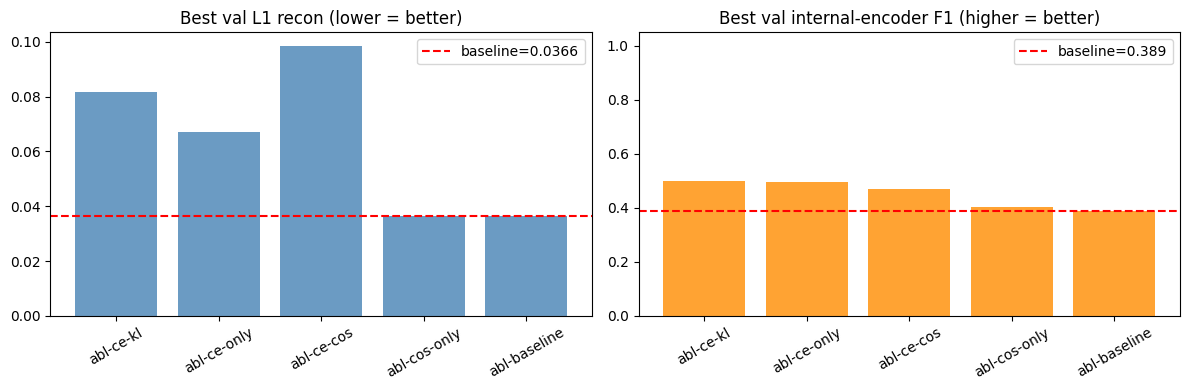

In [12]:
import matplotlib.pyplot as plt

df = pd.DataFrame(results)
baseline_recon = df.loc[df["name"] == "abl-baseline", "best_recon"].iloc[0]
baseline_f1 = df.loc[df["name"] == "abl-baseline", "best_f1"].iloc[0]
df["recon_delta_pct"] = (df["best_recon"] - baseline_recon) / baseline_recon * 100
df["f1_delta"] = df["best_f1"] - baseline_f1
df = df.sort_values("best_f1", ascending=False).reset_index(drop=True)

print("\n=== Ablation results (sorted by val F1) ===")
print("Note: baseline saves by recon (no emotion gradient); emotion configs save by F1.")
print(df[["name", "checkpoint_by", "w_ce", "w_cos", "w_kl",
          "best_recon", "recon_delta_pct", "best_f1", "f1_delta"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
order = df["name"].tolist()

axes[0].bar(order, df["best_recon"], color="steelblue", alpha=0.8)
axes[0].axhline(baseline_recon, color="red", ls="--", label=f"baseline={baseline_recon:.4f}")
axes[0].set_title("Best val L1 recon (lower = better)")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend()

axes[1].bar(order, df["best_f1"], color="darkorange", alpha=0.8)
axes[1].axhline(baseline_f1, color="red", ls="--", label=f"baseline={baseline_f1:.3f}")
axes[1].set_title("Best val internal-encoder F1 (higher = better)")
axes[1].tick_params(axis="x", rotation=30)
axes[1].set_ylim(0, 1.05)
axes[1].legend()
plt.tight_layout()
plt.show()

In [13]:
from scipy import stats
from sklearn.metrics import precision_recall_fscore_support


def _load_state_dict(path):
    try:
        return torch.load(path, map_location=DEVICE, weights_only=True)
    except TypeError:
        return torch.load(path, map_location=DEVICE)


@torch.no_grad()
def predict_per_sample(model, loader):
    model.eval()
    recons, preds, labels = [], [], []
    for batch in tqdm(loader, leave=False):
        mel = batch["mel"].to(DEVICE)
        face_in = batch["face_input"].to(DEVICE)
        gt = batch["gt"].to(DEVICE)
        B, T = mel.shape[0], mel.shape[1]
        gens = []
        per = torch.zeros(B, device=DEVICE)
        for t in range(T):
            g = model(mel[:, t], face_in[:, t])
            gens.append(g)
            per += F.l1_loss(g, gt[:, t], reduction="none").mean(dim=(1, 2, 3))
        per /= T
        recons.extend(per.cpu().tolist())
        v_logits = compute_video_logits(torch.stack(gens, dim=1))
        preds.extend(v_logits.argmax(dim=1).cpu().tolist())
        labels.extend(batch["emotion"].tolist())
    return np.array(recons), np.array(preds), np.array(labels)


per_config = {}
for r in results:
    ckpt = OUT_DIR / r["name"] / "wav2lip.pth"
    if not ckpt.exists():
        continue
    m = load_wav2lip(WAV2LIP_CKPT, DEVICE)
    m.load_state_dict(_load_state_dict(ckpt))
    per_config[r["name"]] = predict_per_sample(m, val_loader)
    del m
    torch.cuda.empty_cache()

base_recon, base_pred, base_lab = per_config["abl-baseline"]

rows = []
for name in [r["name"] for r in results]:
    if name == "abl-baseline":
        continue
    recon, pred, lab = per_config[name]
    n = min(len(recon), len(base_recon))
    # L1 paired Wilcoxon
    try:
        _, p_recon = stats.wilcoxon(base_recon[:n], recon[:n])
    except ValueError:
        p_recon = float("nan")
    # McNemar on emotion correctness
    b_ok = (base_pred[:n] == base_lab[:n])
    e_ok = (pred[:n] == lab[:n])
    n01 = int((b_ok & ~e_ok).sum())
    n10 = int((~b_ok & e_ok).sum())
    chi2 = (abs(n01 - n10) - 1) ** 2 / max(n01 + n10, 1)
    p_mcnemar = 1 - stats.chi2.cdf(chi2, df=1) if (n01 + n10) > 0 else 1.0
    prec, rec, f1, _ = precision_recall_fscore_support(
        lab, pred, labels=list(range(NUM_EMO)), zero_division=0)
    _, _, bf1, _ = precision_recall_fscore_support(
        base_lab, base_pred, labels=list(range(NUM_EMO)), zero_division=0)
    rows.append({
        "config": name,
        "Δ recon": recon.mean() - base_recon.mean(),
        "p_recon": p_recon,
        "Δ F1 (macro)": float(np.mean(f1)) - float(np.mean(bf1)),
        "McNemar p": p_mcnemar,
        "n10 (base→best)": n10,
        "n01 (best→base)": n01,
    })

sig_df = pd.DataFrame(rows)
print("\n=== Significance vs. baseline (val split) ===")
print(sig_df.to_string(index=False))
print("\nInterpretation:\n"
      "  - Δ recon ≈ 0 and p_recon > 0.05: reconstruction not hurt.\n"
      "  - Δ F1 > 0 and McNemar p < 0.05: emotion meaningfully improved.\n"
      "  - External-classifier evaluation (06_external_evaluation.ipynb) confirms on test split.")


=== Significance vs. baseline (val split) ===
      config   Δ recon      p_recon  Δ F1 (macro)  McNemar p  n10 (base→best)  n01 (best→base)
abl-cos-only -0.001882 8.606877e-01      0.020500   0.867632               19               17
 abl-ce-only  0.039787 7.730475e-23      0.103203   0.177530               33               22
  abl-ce-cos  0.106911 6.043833e-24      0.094689   0.245278               35               25
   abl-ce-kl  0.067415 7.429997e-23      0.051930   0.619796               35               30

Interpretation:
  - Δ recon ≈ 0 and p_recon > 0.05: reconstruction not hurt.
  - Δ F1 > 0 and McNemar p < 0.05: emotion meaningfully improved.
  - External-classifier evaluation (06_external_evaluation.ipynb) confirms on test split.
